# GenAI‑Net (RL4CRN) Tutorial 01 — Logic Circuit Task (Deep Dive)

This notebook is a **reference tutorial** for the *Logic Circuit* task. It’s intentionally more verbose than the other notebooks in the tutorial series.

**What you’ll learn**
1. The mental model: **Task → Session → Trainer → Best CRN**
2. How the *logic task* is defined: scenarios (`u_list`), targets, weights, and reward
3. How training works end‑to‑end: wiring, running, inspection, and checkpointing
4. How to define **custom logic problems** (new truth tables / new I/O sizes)
5. How to debug common issues (reward, solver stability, training plateaus)

---

## Notebook assumptions
- You’re running from the repository root and have installed the package:
```bash
pip install -e .
```
- You have a working `RL4CRN` installation and its dependencies.

> Tip: keep this notebook as the “canonical reference”. The other notebooks can link back here for details.


---
## 0) Environment sanity check


In [1]:
import os, sys, numpy as np

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())


Python: 3.10.12
CWD: /local0/home/mfilo/git/CRN-GenerativeAI/tutorial


---
## 1) Imports and the high‑level API

This tutorial uses the **standard interface layer** in `RL4CRN/utils/input_interface.py`:

- `Configurator`: presets + overrides (central place to tune experiments)
- `make_task`: standardized task builder (`kind="logic"`, etc.)
- `make_session_and_trainer`: wiring for template/library/env/policy/agent/trainer

If you learn **one pattern**, learn this:

1. Configure: `cfg = Configurator.preset(...)` then set `cfg.task.*`, `cfg.train.*`, ...
2. Build: `session, trainer = make_session_and_trainer(cfg)`
3. Train: `trainer.run(...)`
4. Inspect: `trainer.inspect_best(...)`
5. Save/Resume: `trainer.load(...)`


In [2]:
from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
)

from RL4CRN.utils.visualizations import plot_truth_table


---
## 2) Logic Circuit task: concept

A **logic circuit task** asks for a CRN that implements a Boolean function:

\[
f:\{0,1\}^{n_{\text{inputs}}} \rightarrow \{0,1\}
\]

The tutorial setup is:

- Inputs are provided as a vector `u` of length `n_inputs` (values in `{0,1}`).
- The task enumerates all input combinations (truth table) into `u_list`.
- The target output is `r = f(u)` (often represented as `0.0/1.0` float).
- Training searches over CRNs (reaction additions) to minimize a loss based on how well the CRN output matches the truth table.

**You can customize**:
- number of inputs (`n_inputs`)
- the logic function `logic_fn(u)`
- how you weight the trajectory (steady state vs transient)
- time horizon / time grid


---
## 3) Helper utilities (notebook‑local)

These keep outputs clean and make it easy to reuse the same checks when defining custom logic functions.


In [3]:
def print_task_summary(task, max_preview=3):
    """Compact TaskSpec summary."""
    print("Task:", task.name)
    print("time_horizon:", task.time_horizon.shape, f"[0..{task.time_horizon[-1]}]")
    print("num scenarios:", len(task.u_list))
    if len(task.u_list) > 0:
        print(f"first {min(max_preview, len(task.u_list))} u:", task.u_list[:max_preview])
    print()


def run_smoke_reward(task, state, label=""):
    """Call task.compute_reward on a given state and print normalized output."""
    out = task.compute_reward(state)
    if isinstance(out, tuple):
        loss, info = out
    else:
        loss, info = out, {}
    print(f"[reward smoke{(' - ' + label) if label else ''}] loss={float(loss):.6g} | info_keys={list(info.keys())[:10]}")
    return out


---
## 4) Define a logic function (truth table)

We’ll start with a simple 3‑input Boolean function:

\[
f(u_0,u_1,u_2) = (u_0 \wedge \neg u_1) \vee u_2
\]

You can replace this with your own function as long as it maps `u -> bool`.


In [4]:
# 3-input example logic
logic_fn = lambda u: (bool(u[0]) and (not bool(u[1]))) or bool(u[2])

# Labels are purely for readability / plotting
species_labels = [f"X_{i+1}" for i in range(3)] + ["OUT"]

print("species_labels:", species_labels)


species_labels: ['X_1', 'X_2', 'X_3', 'OUT']


---
## 5) Build the TaskSpec (standalone)

In this section we build the **logic task only** (no training yet), to confirm:

- the scenarios exist (`task.u_list`)
- the time grid makes sense
- reward can be evaluated on a template state later

Key knobs:
- `weights="steady_state"`: emphasize final value / steady state matching
- `t_f`, `n_t`: simulation horizon and discretization


Task: logic
time_horizon: (200,) [0..100.0]
num scenarios: 8
first 3 u: [array([0., 0., 0.], dtype=float32), array([0., 0., 1.], dtype=float32), array([0., 1., 0.], dtype=float32)]



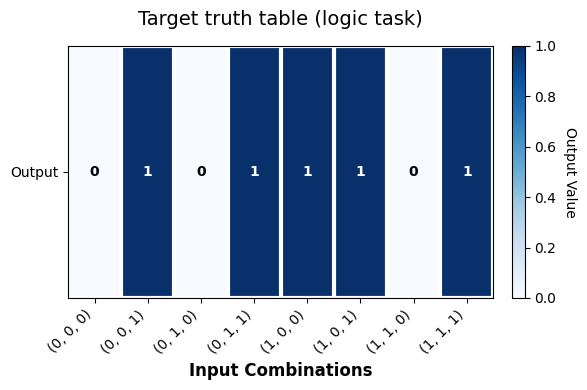

In [6]:
task = make_task(
    kind="logic",
    species_labels=species_labels,
    n_inputs=3,
    logic_fn=logic_fn,
    ic="zero",
    weights="steady_state",
    t_f=100, n_t=200,
)

print_task_summary(task)

# Plot the target truth table
r_list = [np.array([float(bool(logic_fn(u)))], dtype=np.float32) for u in task.u_list]
plot_truth_table(task.u_list, r_list, title="Target truth table (logic task)")
pass


---
## 6) Configure an experiment (cfg)

We’ll use a *fast* preset and override only what matters.

**Recommended tutorial convention**
- Keep `cfg.task.*` edits grouped together.
- Keep `cfg.train.*` edits grouped together.
- Put solver/library details in one cell (easy to copy/paste).

> For “reference” runs, you can increase `epochs`, and for CI/smoke tests keep it small.


In [7]:
cfg = Configurator.preset("fast")

# ---- Task config (logic) ----
cfg.task.kind = "logic"
cfg.task.n_inputs = 3
cfg.task.logic_fn = logic_fn
cfg.task.t_f = 100.0
cfg.task.N_t = 200
cfg.task.weights = "steady_state"
cfg.task.ic_value = 0.01

# ---- Train config ----
cfg.train.max_added_reactions = 5
cfg.train.epochs = 30
cfg.train.render_every = 5
cfg.train.seed = 0

# ---- Library / solver (advanced knobs) ----
cfg.library.order = 2
cfg.library.include_dilution = False

cfg.solver.algorithm = "CVODE"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10


---
## 7) Build Session + Trainer (full wiring)

This is where the “full stack” gets assembled:
- template CRN
- library of candidate reactions / operators
- environment interface and reward wiring
- agent/policy and trainer loop

After construction you can access:
- `session.task` (the TaskSpec)
- `session.crn_template` (the starting state)
- `trainer` methods (`run`, `inspect_best`, `best_crn`, `load`, ...)

> If anything breaks later, rebuild up to this point and re-run the reward smoke test.


In [ ]:
session, trainer = make_session_and_trainer(cfg, device="auto")

print(f"Device: {session.device}")
print(f"CPUs: {session.n_cpus} | Batch size: {session.batch_size}")
print(f"Task: {session.task.name} | Inputs: {cfg.task.n_inputs} | Max steps: {cfg.train.max_added_reactions}")
print()

# Plot target truth table again (from session.task.u_list)
u_list = session.task.u_list
r_list = [np.array([float(bool(cfg.task.logic_fn(u)))], dtype=np.float32) for u in u_list]
plot_truth_table(u_list, r_list, title="Target truth table (session task)")

print("Template IO-CRN:")
print(session.crn_template)


---
## 8) Reward smoke test (before training)

Before spending compute, verify that:
- reward runs on the template CRN
- loss is finite (not NaN/Inf)
- `info` dictionary exists and has useful keys (varies by task)

If this fails, the issue is **not** RL—it’s usually the solver, ICs, or a mis‑specified task.


In [ ]:
run_smoke_reward(session.task, session.crn_template, label="template")

---
## 9) Train (stop/resume friendly)

- `trainer.run(...)` is usually Ctrl+C safe.
- If you pass `checkpoint_path`, it can save periodically and on interrupt.

We recommend:
- always checkpoint for long runs
- treat checkpoints as experiment artifacts (commit hashes + config snapshots help a lot)


In [ ]:
checkpoint_path = "logic_task_chkpt.pkl"
trainer.run(epochs=cfg.train.epochs, checkpoint_path=checkpoint_path)


---
## 10) Inspect the best solution

`inspect_best(plot=True)` should:
- show how the learned CRN matches the truth table
- provide a readable summary (loss, reward terms, etc.)

Also check:
- `trainer.best_crn()` and its metadata
- hall-of-fame size (if available in your environment wrapper)


In [ ]:
trainer.inspect_best(plot=True)

best = trainer.best_crn()
print("Hall of Fame size:", len(session.mult_env.hall_of_fame))
if best is not None:
    print("Best loss:", best.last_task_info.get("reward", None))


---
## 11) Resume from checkpoint (roundtrip test)

A good tutorial includes this because it’s the difference between a “cool demo” and a usable workflow.


In [ ]:
session2, trainer2 = make_session_and_trainer(cfg, device="auto")
trainer2.load(checkpoint_path)
trainer2.inspect_best(plot=True)


---
## 12) Custom logic problems (the main recipe)

This is the key section for users.

### Recipe
1. Choose `n_inputs`
2. Define `logic_fn(u)` returning `bool`
3. Update `species_labels` (inputs + OUT)
4. Rebuild `cfg` + session/trainer
5. Plot truth table target before training

Below are three examples you can use as templates.


### 12.1) Example A — XOR (2 inputs)

In [ ]:
xor_fn = lambda u: bool(u[0]) ^ bool(u[1])

species_labels_xor = ["X_1", "X_2", "OUT"]
task_xor = make_task(
    kind="logic",
    species_labels=species_labels_xor,
    n_inputs=2,
    logic_fn=xor_fn,
    ic="zero",
    weights="steady_state",
    t_f=80, n_t=160,
)
print_task_summary(task_xor)
r_list = [np.array([float(bool(xor_fn(u)))], dtype=np.float32) for u in task_xor.u_list]
plot_truth_table(task_xor.u_list, r_list, title="Target truth table (XOR)")


### 12.2) Example B — Majority vote (3 inputs)

Output is 1 if at least two inputs are 1.


In [ ]:
maj3_fn = lambda u: (int(bool(u[0])) + int(bool(u[1])) + int(bool(u[2]))) >= 2

species_labels_maj = ["X_1", "X_2", "X_3", "OUT"]
task_maj = make_task(
    kind="logic",
    species_labels=species_labels_maj,
    n_inputs=3,
    logic_fn=maj3_fn,
    ic="zero",
    weights="steady_state",
    t_f=100, n_t=200,
)
print_task_summary(task_maj)
r_list = [np.array([float(bool(maj3_fn(u)))], dtype=np.float32) for u in task_maj.u_list]
plot_truth_table(task_maj.u_list, r_list, title="Target truth table (Majority-3)")


### 12.3) Example C — Custom truth table directly

Sometimes you don’t want to write Boolean logic; you have a truth table.
Below we encode a truth table for 3 inputs using a dict mapping.


In [ ]:
# Truth table mapping for 3 inputs (u0,u1,u2) -> out
# Example: implement NOT(u0) OR (u1 AND u2)
tt = {
    (0,0,0): 1,
    (0,0,1): 1,
    (0,1,0): 1,
    (0,1,1): 1,
    (1,0,0): 0,
    (1,0,1): 0,
    (1,1,0): 0,
    (1,1,1): 1,
}

tt_fn = lambda u: bool(tt[tuple(int(bool(x)) for x in u)])

species_labels_tt = ["X_1", "X_2", "X_3", "OUT"]
task_tt = make_task(
    kind="logic",
    species_labels=species_labels_tt,
    n_inputs=3,
    logic_fn=tt_fn,
    ic="zero",
    weights="steady_state",
    t_f=100, n_t=200,
)
print_task_summary(task_tt)
r_list = [np.array([float(bool(tt_fn(u)))], dtype=np.float32) for u in task_tt.u_list]
plot_truth_table(task_tt.u_list, r_list, title="Target truth table (Custom TT)")


---
## 13) Debugging checklist (logic task)

### Reward and solver
- If `loss` is NaN/Inf:
  - reduce `t_f` / `N_t`
  - relax tolerances `rtol/atol`
  - check ICs (e.g., `ic_value`)
- If reward is always identical across actions:
  - verify `weights` (steady_state vs transient)
  - verify output species label matches expected “OUT” location

### Training behavior
- If training plateaus quickly:
  - increase `max_added_reactions`
  - increase `epochs`
  - check exploration settings in your preset (policy/agent parameters)
- If training is unstable:
  - set a fixed seed
  - reduce batch size / parallelism
  - tighten constraints or normalize reward terms (task dependent)

### Reproducibility
- Record: git commit hash, full `cfg` dump, random seeds, checkpoint path.


---
## 14) Appendix — Print the full configuration

This is useful for copy/paste into experiment logs.


In [8]:
cfg.describe()

{'task': {'kind': 'logic',
          'n_inputs': 3,
          'logic_fn': <function <lambda> at 0x7ff142698430>,
          't_f': 100.0,
          'N_t': 200,
          'ic_value': 0.01,
          'weights': 'steady_state',
          'target': None,
          'target_fn': None,
          'dose_range': None},
 'solver': {'algorithm': 'CVODE', 'rtol': 1e-10, 'atol': 1e-10},
 'train': {'epochs': 30,
           'max_added_reactions': 5,
           'render_every': 5,
           'hall_of_fame_size': 30,
           'batch_multiplier': 10,
           'seed': 0,
           'n_cpus': None,
           'batch_size': None},
 'library': {'order': 2, 'include_dilution': False},
 'policy': {'width': 256,
            'depth': 2,
            'deep_layer_size': 512,
            'continuous_distribution': {'type': 'lognormal_1D'},
            'entropy_weights_per_head': {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0},
            'ordering_enabled': False,
            'const